In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.style.use('max_style.mplstyle')

from numba.experimental import jitclass
import numba as nb
from scipy.interpolate import interp1d

from tqdm import tqdm
from time import time
from spl import spline

%matplotlib inline

# <center>Define Verlet and System Base Class</center><a id="first-bullet"></a>

In [12]:
class verlet():
    def getAcc(self, positions, _):
        """
        simple harmonic oscillator.
        This is for testing purposes. The user should 
        overload this function in order to implement the system
        that should be simulated. 
        (like multiple ions interact with eachother)
        """
        
        return -positions
    
    def integrate(self, endtime, dt):
        """
        calculate the trajectory for N Ions in M Dimensions.
        implemented shortened velocity verlet from:
        https://en.wikipedia.org/wiki/Verlet_integration
        assumes, that acceleration only depends on position.

        Parameters
        ----------
        self.getAcc : function(array) : array
            verlet integrates only, so acceleration function
            needs to implemented by the user!
            see getAcc docstring

        endtime : float
            Seconds on where to end simulation.

        dt : float
            step size between each evaluation step in Seconds.
            With our setup of iontraps less or equal to
            5e-9 is recommended! (redtrap)

        Returns
        -------
        tpoints : np.array
            points of all evaluated timesteps

        ppoints : np.array
            ppoints[:, 0, 0, 0]
                    |  |  |  |
                    |  |  |  > dimension x (or general 1st dim)
                    |  |  > 0 is position, 
                    |  |    1 velocity, 2 acceleration
                    |  > choose ion #0
                    > all timesteps
        """

        n = int(endtime / dt)
        shape = (n,) + self.ions.shape
        tpoints = np.linspace(0, endtime, n)
        ppoints = np.empty(shape, dtype=np.float64)

        ppoints[0] = self.ions

        # iterate through all timepoints, see wiki link in docstring
        for k in range(len(tpoints)-1):
            ppoints[k+1, :, 0] = ppoints[k, :, 0] + ppoints[k, :, 1] * dt + 0.5 * ppoints[k, :, 2] * dt**2
            ppoints[k+1, :, 2] = self.getAcc(ppoints[k+1, :, 0, 0], k+1)
            ppoints[k+1, :, 1] = ppoints[k, :, 1] + 0.5 * (ppoints[k, :, 2] + ppoints[k+1, :, 2]) * dt

        return tpoints, ppoints

In [13]:
spec = [('ions', nb.float64[:, :, :]),
        ('trap', nb.float64[:, :, :]),
        ('splcoeff', nb.float64[:, :, :]),
        ('volt', nb.float64[:, :]),
        ('qdm', nb.float64),]

@jitclass(spec)
class red_system(verlet, spline):
    def __init__(self, trap):
        
        self.splcoeff = np.empty(trap.shape)
        
        for i in range(len(trap)):
            self.splcoeff[i, 0] = self.splrep(trap[i, 0], trap[i, 1])
            self.splcoeff[i, 1] = self.splrep(trap[i, 0], trap[i, 2])
        
        self.trap = trap
        
        q = 1.60217662e-19
        m = 1.66054e-27*39.96259
        self.qdm = q/m
        
    def propagate(self, ramp, endtime, dt):
        n = int(endtime / dt)
        tpoints = np.linspace(0, endtime, n)
        
        self.volt = np.zeros((len(ramp)-1, n))
        for i in range(len(ramp)-1):
            self.volt[i] = np.interp(tpoints, ramp[0], ramp[i+1])
        
        return self.integrate(endtime, dt)
        
        
    def setIons(self, positions):
        """
        set the initial positions of the ions.
        
        Parameters
        ----------
        posistions : np.array
            has size (#numberOfIons, positions).
            For one dim (x, 3, 1), for 3 dim (x, 3, 3)
            with position, velocity, acceleration
        """
        self.ions = positions
    
    def getAcc(self, position, k):
        acc = np.zeros(position.shape)
        
        for i in range(len(self.trap)):
            acc += self.volt[i, k] * self.splev(position, self.trap[i, 0], self.trap[i, 2], self.splcoeff[i, 1])
            
        return acc * self.qdm
    
    def getPot(self, position, k):
        # TODO find out what k is
        pot = np.zeros(position.shape)
        
        for i in range(len(self.trap)):
            pot += self.volt[i, k] * self.splev(position, self.trap[i, 0], self.trap[i, 1], self.splcoeff[i, 0])
            
        return pot

### load trap geometry <a id="load-trap-geometry"></a>

In [14]:
trap = np.load('redtrap.npy')
trap[:, 0] *= 1e-3
trap[:, 1:] *= 2
trap.shape

(16, 3, 12869)

## Plot the Poential with 1V applied
(multiply with any value; potential scales linearly with applied voltage)


### Task:
- read the paper from Ferdinand and calculate the trap frequency with the potential below

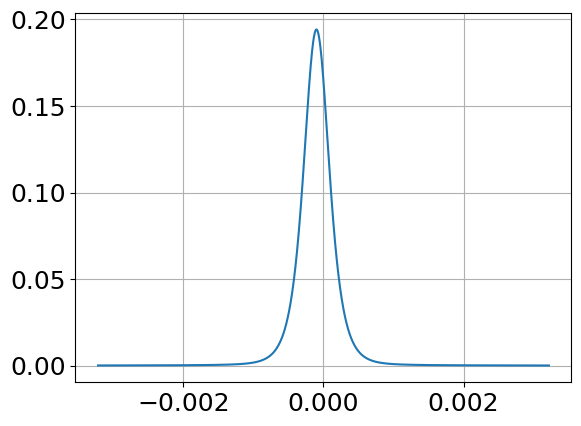

In [15]:
plt.plot(trap[15, 0], trap[15,1])

## Find out wheter the middle of segment 15 is nummerically also the minima of the potential

x should be:

x: [-1.000e-04]

In [16]:
from scipy.optimize import minimize

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -0.194124481528973
        x: [-3.000e-04]
      nit: 2
      jac: [ 2.485e-03]
 hess_inv: [[ 1.499e-07]]
     nfev: 90
     njev: 39


array([-0.02970002])

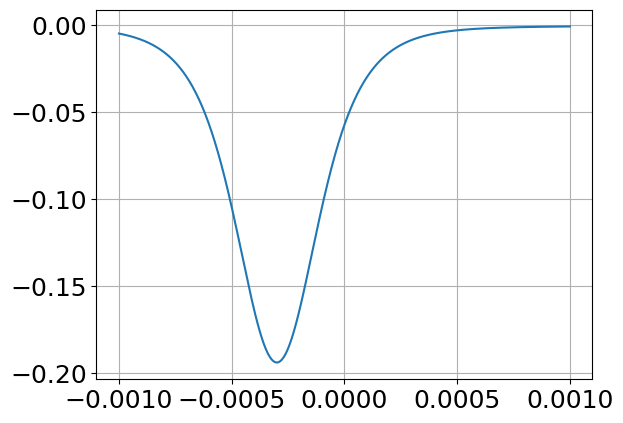

In [17]:
redtrap = red_system(trap)  
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))
voltage = np.zeros((16, 1))
voltage[14, 0] = -1
redtrap.volt = voltage
print(minimize(lambda t: redtrap.getPot(t, 0), 300e-6))

x = np.linspace(-1e-3, 1e-3, 1000)
plt.plot(x, redtrap.getPot(x, 0))
redtrap.getPot(np.array([100e-6]), 0)

In [18]:
hbar = 6.62607015e-34 / 2 / np.pi
omega = 9.83511943e+06
hbar_omega = hbar * omega

# in eV
hbar_omega = hbar_omega / 1.602176634e-19

## Now we implement a Transport from segment 15 to segment 16
### Task:
- replace the redramp with a precompensated transport ramp and see what the excitation quanta is
- **double check:**
  - is the ion starting at the middle of the potential of segment 15?
  - is the ion adning at the center of segment 16 when the transport ended?
    (even if so, does it have kinetic energy?)

In [19]:
result = []
redramp = np.load('redramp.npy')

transport = np.zeros((17, 54), dtype=np.float64)
transport[[0, 15, 16], :54] = redramp[:, :54]

redtrap = red_system(trap)  
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

t, p = redtrap.propagate(transport, transport[0, -1], 5e-10)

volt = redtrap.getPot(p[-1, :, 0, 0], -1)
volt0 = redtrap.getPot(p[0, :, 0, 0], 0)
    
c = 299792458
massunit = 931.49410242e6/c**2
mCa40 = 39.962590866 * massunit

energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

print(energy / hbar_omega)

[66.09894114]


In [20]:
result = []
redramp = np.load('redramp.npy')

transport = np.zeros((17, len(redramp[0])), dtype=np.float64)
transport[[0, 15, 16]] = redramp

redtrap = red_system(trap)  
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

t, p = redtrap.propagate(transport, transport[0, -1], 5e-9)

volt = redtrap.getPot(p[-1, :, 0, 0], -1)
volt0 = redtrap.getPot(p[0, :, 0, 0], 0)

c = 299792458
massunit = 931.49410242e6/c**2
mCa40 = 39.962590866 * massunit

energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

print(energy / hbar_omega)

[75.96217604]


In [23]:
result = []
redramp = np.load('redramp.npy')

# transport array is one row bigger than the number of trap segments
# first entry is time 
transport = np.zeros((17, 54), dtype=np.float64)
transport[[0, 15, 16], :54] = redramp[:, :54]
#          |
#          time
#              |
#              segment #15
#                   | 
#                   segment #16


# set Ion at -300um e.g. the center of segment 15 of the redtrap
# ( trap segments are 200um wide each )
redtrap = red_system(trap)  
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

    # propagates / simulates the ion trajectory and give back:
    # t: timesteps 
    # p: ppoints : np.array
    #        ppoints[:, 0, 0, 0]
    #                |  |  |  |
    #                |  |  |  > dimension x (or general 1st dim)
    #                |  |  > 0 is position, 
    #                |  |    1 velocity, 2 acceleration
    #                |  > choose ion #0
    #                > all timesteps

# print(f'value 2', transport[0, -1])
# print(redramp[0])


t, p = redtrap.propagate(transport, transport[0, -1], 5e-9)

volt = redtrap.getPot(p[-1, :, 0, 0], -1)
volt0 = redtrap.getPot(p[0, :, 0, 0], 0)
    
    
# masse u in eV
c = 299792458# m/s
massunit = 931.49410242e6/c**2 # eV * s^2 / m^2
mCa40 = 39.962590866 * massunit

# energy in eV
energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

# Print excitation quanta
print(energy / hbar_omega)

[66.14594398]


ValueError: x and y must have same first dimension, but have shapes (54,) and (1,)

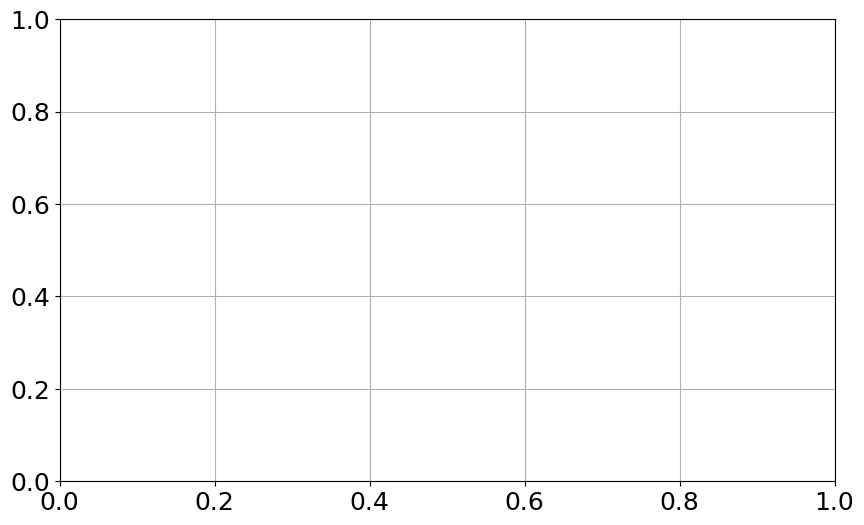

In [22]:
# for segment 15:
precomp_waveform = transport[15, :]  # choose the row representing your waveform
excitation = energy / hbar_omega

# Plot
plt.figure(figsize=(10, 6))
plt.plot(precomp_waveform, excitation, marker='o', linestyle='-')
plt.title("Ion Excitation vs Precompensated Waveform")
plt.xlabel("Precompensated Waveform Voltage [V]")  # adjust units if needed
plt.ylabel("Excitation [ħω]")
plt.grid(True)
plt.show()

### Plot Result Heatmap <a id="restheory"></a>

In [ ]:
r = np.array(result)
fig, ax = plt.subplots(figsize=(12,8))
pc = ax.pcolormesh(r[:, 0].reshape((-1, 30))*1e6, 
                   r[:, 1].reshape((-1, 30))*20, 
                   r[:, 2].reshape((-1, 30))/hbar_omega, cmap='coolwarm')

cbar = fig.colorbar(pc)
cbar.set_label(r'n [$\hbar\omega$]')
ax.set_title('Ion excitation')
ax.set_xlabel("dwelltime [us]")
ax.set_ylabel("transporttime [us]")